# [TP1] procesamiento de archivos PDF

*Alumno: Moises Lobayza*

# 1. Adquisición y metadatos

Installamos la libreria recomendada

In [49]:
!pip install pymupdf

Descargamos el pdf de **Índice de Precios al Consumidor de Marzo 2026 publicado recientemente el 14/04/2026 por le INDEC**

In [50]:
import requests

# The PDF URL provided by the user
pdf_url = "https://www.indec.gob.ar/uploads/informesdeprensa/ipc_04_26853171E136.pdf"

# Define the filename to save the PDF
filename = "ipc_marzo_26.pdf"

try:
    response = requests.get(pdf_url, stream=True)
    response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)

    with open(filename, 'wb') as pdf_file:
        for chunk in response.iter_content(chunk_size=8192):
            pdf_file.write(chunk)
    print(f"PDF successfully downloaded and saved as '{filename}'")
except requests.exceptions.RequestException as e:
    print(f"Error downloading the PDF: {e}")

PDF successfully downloaded and saved as 'ipc_marzo_26.pdf'


Abrimos el pdf y analizamos los metadatos

In [51]:
import fitz  # PyMuPDF

try:
    # Abrimos el documento PDF
    doc = fitz.open(filename)

    # Accedemos a los metadatos
    metadata = doc.metadata

    print("PDF Metadata:")

    if metadata:
        for key, value in metadata.items():
            print(f"  {key}: {value}")
    else:
        print("  No metadata found for this PDF.")

    print("\nMetadatos solicitados por la consigna:")
    print(f"  Título: {metadata.get('title', 'No disponible')}")
    print(f"  Autor: {metadata.get('author', 'No disponible')}")
    print(f"  Número de páginas: {doc.page_count}")
    print(f"  Software de creación: {metadata.get('creator', 'No disponible')}")

    # Cerramos el documento
    doc.close()

except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found. Please ensure it was downloaded correctly.")
except Exception as e:
    print(f"An error occurred while trying to access PDF metadata: {e}")

PDF Metadata:
  format: PDF 1.7
  title: Índice de precios al consumidor (IPC). Cobertura nacional. Marzo de 2026
  author: Instituto Nacional de Estadística y Censos (INDEC)
  subject: Índice de precios al consumidor (IPC). Cobertura nacional

  keywords: 
  creator: Adobe InDesign 21.3 (Windows)
  producer: Adobe PDF Library 18.0
  creationDate: D:20260414121221-03'00'
  modDate: D:20260414145035-03'00'
  trapped: 
  encryption: None

Metadatos solicitados por la consigna:
  Título: Índice de precios al consumidor (IPC). Cobertura nacional. Marzo de 2026
  Autor: Instituto Nacional de Estadística y Censos (INDEC)
  Número de páginas: 20
  Software de creación: Adobe InDesign 21.3 (Windows)


**Conclusión:**
En esta primera etapa se logró automatizar la descarga del archivo PDF desde una fuente pública y acceder correctamente a sus metadatos mediante la librería PyMuPDF. Se identificaron los datos principales solicitados por la consigna, como el título, el autor, la cantidad de páginas y el software de creación del documento. Esta etapa es importante porque permite validar que el archivo fue descargado correctamente y conocer su estructura básica antes de avanzar con la extracción del texto y el análisis posterior.


# 2. Análisis estructural del texto

In [52]:
try:
    # Abrimos el documento PDF
    doc = fitz.open(filename)

    extracted_text = []

    # Recorremos las primeras 5 páginas o menos si el PDF tiene menos
    for page_num in range(min(5, doc.page_count)):
        page = doc.load_page(page_num)

        # Extraemos el texto por bloques para conservar mejor la estructura visual
        blocks = page.get_text("blocks")

        # Ordenamos los bloques de arriba hacia abajo y de izquierda a derecha
        blocks = sorted(blocks, key=lambda b: (b[1], b[0]))

        page_text = f"\n========== PÁGINA {page_num + 1} ==========\n\n"

        for block in blocks:
            block_text = block[4].strip()  # el texto del bloque está en la posición 4
            if block_text:
                page_text += block_text + "\n\n"

        extracted_text.append(page_text)

    # Unimos todas las páginas
    full_text = "\n".join(extracted_text)

    print("Texto extraído de las primeras 5 páginas en formato más crudo:\n")
    print(full_text)

    # Cerramos el documento
    doc.close()

except FileNotFoundError:
    print(f"Error: El archivo '{filename}' no fue encontrado.")
except Exception as e:
    print(f"Ocurrió un error al extraer el texto del PDF: {e}")

Texto extraído de las primeras 5 páginas en formato más crudo:


========== PÁGINA 1 ==========

ISSN 2545-6636
Informes técnicos / Vol. 10, n° 91

Índices de precios
Vol. 10, n° 11

Índice de precios 
al consumidor (IPC)

Marzo de 2026



========== PÁGINA 2 ==========

Índice	
Pág.

Informes técnicos. Vol. 10, nº 91
ISSN 2545-6636

Resumen ejecutivo............................................................................................3

Índices de precios. Vol. 10, nº 11

ISSN 2545-6725

Cuadros

Índice de precios al consumidor. 
Cobertura nacional

Cuadro 1. Variaciones de marzo con respecto al mes anterior, según 
divisiones. Total nacional y regiones .................................................................5

Cuadro 2. Variaciones de marzo con respecto a diciembre de 2025,  
según divisiones. Total nacional y regiones........................................................6

Marzo de 2026

Cuadro 3. Variaciones de marzo con respecto al mismo mes de 2025,  
según divis

**Análisis del texto extraído:**
La extracción de las primeras cinco páginas permitió observar que el texto conserva varios saltos de línea y parte de la estructura original del PDF. Se distinguen títulos, subtítulos, bloques de texto, apartados del índice y, en algunas páginas, fragmentos de tablas y gráficos. También se nota que muchas frases aparecen cortadas en varias líneas, siguiendo la disposición visual del documento original.

**Separadores identificados:**
El separador principal en este PDF es el salto de línea (`\n`). Además, aparecen líneas en blanco entre bloques, algunas tabulaciones (`\t`) y secuencias de puntos en el índice para unir títulos con números de página. También hay cortes de línea producidos por el diseño de la página.

**Conclusión:**
En esta etapa se logró extraer el texto de las primeras cinco páginas conservando parte de su estructura. Esto permitió identificar cómo se organizan los contenidos y reconocer los principales separadores del documento, lo que sirve como base para las siguientes etapas de limpieza y análisis.


# 3. Extracción de datos tabulares

Intalamos la librería recomendada

In [53]:
!pip install pdfplumber

In [54]:
import pdfplumber
import pandas as pd

try:
    with pdfplumber.open(filename) as pdf:
        # La página 5 es la seleccionada la cual corresponde al índice 4
        page = pdf.pages[4]

        print(f"Intentando extraer tablas de la PÁGINA {page.page_number} usando pdfplumber...")

        # Extraemos las tablas de la página
        tables = page.extract_tables()

        if tables:
            print(f"Se encontraron {len(tables)} tabla(s) en la página {page.page_number}.")

            # Asumiendo que la tabla de interés es la primera (puedes ajustar el índice si hay más)
            table_data = tables[0]

            # Convertimos la tabla extraída a un DataFrame de Pandas
            # La primera fila suele ser los encabezados, las demás los datos
            df_table = pd.DataFrame(table_data[1:], columns=table_data[0])

            print("\nContenido de la tabla extraída (primeras 5 filas):")
            display(df_table.head())
        else:
            print(f"No se encontraron tablas en la página {page.page_number} con pdfplumber.")

except FileNotFoundError:
    print(f"Error: El archivo '{filename}' no fue encontrado. Asegúrese de que se descargó correctamente.")
except Exception as e:
    print(f"Ocurrió un error al intentar extraer tablas con pdfplumber: {e}")

Intentando extraer tablas de la PÁGINA 5 usando pdfplumber...
Se encontraron 1 tabla(s) en la página 5.

Contenido de la tabla extraída (primeras 5 filas):


,Nivel general y divisiones,Nacional,Región geográfica del país,None,None,None,None,None
0,None,None,GBA,Pampeana,Noreste,Noroeste,Cuyo,Patagonia
1,,Porcentaje,None,None,None,None,None,None
2,Nivel general,"3,4","3,4","3,3","4,1","4,0","3,2","2,5"
3,Alimentos y bebidas no alcohólicas,"3,4","2,9","3,5","4,5","4,4","4,0","3,2"
4,Bebidas alcohólicas y tabaco,"2,1","2,1","2,2","2,2","2,4","2,1","1,9"


Con `pdfplumber` hemos logrado extraer la tabla directamente y convertirla en un DataFrame de Pandas. Esto es muy útil porque nos permite trabajar con los datos de forma estructurada, facilitando su limpieza y análisis.

Ahora visualicemos la tabla para verificar que tan bien la obtuvimos.

***Conclusión sobre la extracción:*** la tabla puede extraerse casi al 100 %, aunque todavía requiere algunas correcciones para obtener un DataFrame fiel a la tabla original que luego permita analizarla adecuadamente.

Ahora procedamos a realizar lo necesario para logar el df correspondiente.


In [55]:
df_table

,Nivel general y divisiones,Nacional,Región geográfica del país,None,None,None,None,None
0,None,None,GBA,Pampeana,Noreste,Noroeste,Cuyo,Patagonia
1,,Porcentaje,None,None,None,None,None,None
2,Nivel general,"3,4","3,4","3,3","4,1","4,0","3,2","2,5"
3,Alimentos y bebidas no alcohólicas,"3,4","2,9","3,5","4,5","4,4","4,0","3,2"
4,Bebidas alcohólicas y tabaco,"2,1","2,1","2,2","2,2","2,4","2,1","1,9"
5,Prendas de vestir y calzado,"3,1","4,2","2,4","2,5","1,5","1,9","1,2"
6,"Vivienda, agua, electricidad, gas y otros\ncom...","3,7","3,6","3,2","9,7","4,1","3,2","2,1"
7,Equipamiento y mantenimiento del hogar,"1,3","1,3","1,5","0,9","1,2","1,3","0,1"
8,Salud,"2,6","3,0","2,4","2,0","2,4","2,2","2,6"
9,Transporte,"4,1","4,7","3,6","2,5","5,1","3,8","3,1"


Primero generamos una copia para trabajar tranquilos. Eliminamos la fila 1 y reorganizamos lo índices

In [56]:
df_copy = df_table.copy()

# Elimina la fila 1 de la copia
df_copy = df_copy.drop(index=1)

# Reorganiza los índices de la copia
df_copy = df_copy.reset_index(drop=True)

print("Copia de df_table creada (df_copy), fila 1 eliminada y índices reorganizados:")
display(df_copy.head())

Copia de df_table creada (df_copy), fila 1 eliminada y índices reorganizados:


,Nivel general y divisiones,Nacional,Región geográfica del país,None,None,None,None,None
0,None,None,GBA,Pampeana,Noreste,Noroeste,Cuyo,Patagonia
1,Nivel general,"3,4","3,4","3,3","4,1","4,0","3,2","2,5"
2,Alimentos y bebidas no alcohólicas,"3,4","2,9","3,5","4,5","4,4","4,0","3,2"
3,Bebidas alcohólicas y tabaco,"2,1","2,1","2,2","2,2","2,4","2,1","1,9"
4,Prendas de vestir y calzado,"3,1","4,2","2,4","2,5","1,5","1,9","1,2"


Ahora usamos la fila 0 como nombre para las columnas

In [57]:
df_copy.columns = df_copy.iloc[0]
df_copy = df_copy[1:].reset_index(drop=True)
display(df_copy.head())

,None,None,GBA,Pampeana,Noreste,Noroeste,Cuyo,Patagonia
0,Nivel general,"3,4","3,4","3,3","4,1","4,0","3,2","2,5"
1,Alimentos y bebidas no alcohólicas,"3,4","2,9","3,5","4,5","4,4","4,0","3,2"
2,Bebidas alcohólicas y tabaco,"2,1","2,1","2,2","2,2","2,4","2,1","1,9"
3,Prendas de vestir y calzado,"3,1","4,2","2,4","2,5","1,5","1,9","1,2"
4,"Vivienda, agua, electricidad, gas y otros\ncom...","3,7","3,6","3,2","9,7","4,1","3,2","2,1"


Por último, quedaron 2 columnas con valor None. Al tener problemas para renombrarlas directamente decidimos crear nuevos nombres para las columnas(agregando lo que nos hacia falta) y usar estos últimos como los nombres definitivos para nuestras columnas.

In [58]:
new_column_names = ['Nivel general y divisiones', 'Nacional'] + df_copy.columns[2:].tolist()
df_copy.columns = new_column_names
display(df_copy.head())

,Nivel general y divisiones,Nacional,GBA,Pampeana,Noreste,Noroeste,Cuyo,Patagonia
0,Nivel general,"3,4","3,4","3,3","4,1","4,0","3,2","2,5"
1,Alimentos y bebidas no alcohólicas,"3,4","2,9","3,5","4,5","4,4","4,0","3,2"
2,Bebidas alcohólicas y tabaco,"2,1","2,1","2,2","2,2","2,4","2,1","1,9"
3,Prendas de vestir y calzado,"3,1","4,2","2,4","2,5","1,5","1,9","1,2"
4,"Vivienda, agua, electricidad, gas y otros\ncom...","3,7","3,6","3,2","9,7","4,1","3,2","2,1"


Por último visualizamos la tabla de la pagina 5 que querias extraer como un dataframe totalmente utilizable para cualquier fúturo trabajo.

In [59]:
df_copy

,Nivel general y divisiones,Nacional,GBA,Pampeana,Noreste,Noroeste,Cuyo,Patagonia
0,Nivel general,"3,4","3,4","3,3","4,1","4,0","3,2","2,5"
1,Alimentos y bebidas no alcohólicas,"3,4","2,9","3,5","4,5","4,4","4,0","3,2"
2,Bebidas alcohólicas y tabaco,"2,1","2,1","2,2","2,2","2,4","2,1","1,9"
3,Prendas de vestir y calzado,"3,1","4,2","2,4","2,5","1,5","1,9","1,2"
4,"Vivienda, agua, electricidad, gas y otros\ncom...","3,7","3,6","3,2","9,7","4,1","3,2","2,1"
5,Equipamiento y mantenimiento del hogar,"1,3","1,3","1,5","0,9","1,2","1,3","0,1"
6,Salud,"2,6","3,0","2,4","2,0","2,4","2,2","2,6"
7,Transporte,"4,1","4,7","3,6","2,5","5,1","3,8","3,1"
8,Comunicación,"2,9","3,0","2,9","2,8","3,0","2,8","2,7"
9,Recreación y cultura,"3,6","3,2","4,4","1,2","4,8","3,1","1,9"


***Conclusión:***
En esta etapa se logró extraer una tabla del PDF utilizando pdfplumber y convertirla en un DataFrame de Pandas. Luego fue necesario realizar una limpieza básica, corrigiendo encabezados, eliminando filas innecesarias y reorganizando los índices, hasta obtener una tabla ordenada y utilizable para el análisis. Esto muestra que, aunque la extracción automática no siempre recupera la estructura perfecta desde el inicio, con un procesamiento simple posterior es posible transformar la información tabular del PDF en datos estructurados y listos para trabajar.

# 4. Análisis de frecuencias (NLP básico)

Extraigamos texto de la pagina narrativa (pag 18)

In [60]:
page_number_to_extract = 18
page_index = page_number_to_extract - 1

try:
    with fitz.open(filename) as doc:
        if 0 <= page_index < doc.page_count:
            page = doc.load_page(page_index)
            narrative_text = page.get_text("text")
            print(narrative_text)
        else:
            print(f"Error: La página {page_number_to_extract} está fuera del rango del documento.")

except FileNotFoundError:
    print(f"Error: El archivo '{filename}' no fue encontrado.")
except Exception as e:
    print(f"Ocurrió un error: {e}")

18/20
Índice de precios al consumidor. Marzo de 2026
Breve nota metodológica 
El Índice de precios al consumidor (IPC) de la República Argentina mide la evolución de los precios de un conjunto de 
bienes y servicios representativos del gasto de consumo de los hogares residentes en áreas urbanas. Sus resultados se 
publican para el total del país como índice nacional y para Cuyo, GBA, Noreste, Noroeste, Pampeana y Patagonia como 
índices regionales. 
Los lineamientos metodológicos que se utilizan para el cálculo del IPC base diciembre 2016=100 están descriptos en la 
Metodología n° 32, disponible en: https://www.indec.gob.ar/ftp/cuadros/economia/metodologia_ipc_nacional_2019.pdf
La estructura de ponderaciones para las canastas ha sido determinada de manera tal que refleje las proporciones de 
gasto de consumo de los hogares que pertenecen a cada región con base en la Encuesta de Gastos e Ingresos de 
los Hogares 2004/05. Estos gastos fueron actualizados por relativos de precios hasta di

Instalar NLTK

In [61]:
!pip install nltk

Importamos NLTK e instalamos recursos necesarios para la actividad

In [62]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Convertimos el texto en minusculas para poder trabajar

In [63]:
narrative_text_lower = narrative_text.lower()
print("Texto narrativo en minúsculas (primeros 500 caracteres):\n")
print(narrative_text_lower[:500])

Texto narrativo en minúsculas (primeros 500 caracteres):

18/20
índice de precios al consumidor. marzo de 2026
breve nota metodológica 
el índice de precios al consumidor (ipc) de la república argentina mide la evolución de los precios de un conjunto de 
bienes y servicios representativos del gasto de consumo de los hogares residentes en áreas urbanas. sus resultados se 
publican para el total del país como índice nacional y para cuyo, gba, noreste, noroeste, pampeana y patagonia como 
índices regionales. 
los lineamientos metodológicos que se utilizan


Ahora tokenicemos el texto

In [64]:
from nltk.tokenize import word_tokenize

In [65]:
tokens = word_tokenize(narrative_text_lower, language='spanish')
print("Primeros 50 tokens del texto en minúsculas:\n")
print(tokens[:50])

Primeros 50 tokens del texto en minúsculas:

['18/20', 'índice', 'de', 'precios', 'al', 'consumidor', '.', 'marzo', 'de', '2026', 'breve', 'nota', 'metodológica', 'el', 'índice', 'de', 'precios', 'al', 'consumidor', '(', 'ipc', ')', 'de', 'la', 'república', 'argentina', 'mide', 'la', 'evolución', 'de', 'los', 'precios', 'de', 'un', 'conjunto', 'de', 'bienes', 'y', 'servicios', 'representativos', 'del', 'gasto', 'de', 'consumo', 'de', 'los', 'hogares', 'residentes', 'en', 'áreas']


En esta etapa se eliminaron las stopwords en español y los signos de puntuación para conservar únicamente los términos con mayor peso semántico. Esto permite que el análisis de frecuencias refleje mejor las palabras más relevantes del texto.

In [66]:
from nltk.corpus import stopwords
import string

# Obtener las stopwords en español
spanish_stopwords = set(stopwords.words('spanish'))

# Definir los signos de puntuación
punctuation = set(string.punctuation)

# Filtrar tokens: eliminar stopwords y puntuación
filtered_tokens = [word for word in tokens if word not in spanish_stopwords and word not in punctuation]

print("Primeros 50 tokens después de eliminar stopwords y puntuación:\n")
print(filtered_tokens)

Primeros 50 tokens después de eliminar stopwords y puntuación:

['18/20', 'índice', 'precios', 'consumidor', 'marzo', '2026', 'breve', 'nota', 'metodológica', 'índice', 'precios', 'consumidor', 'ipc', 'república', 'argentina', 'mide', 'evolución', 'precios', 'conjunto', 'bienes', 'servicios', 'representativos', 'gasto', 'consumo', 'hogares', 'residentes', 'áreas', 'urbanas', 'resultados', 'publican', 'total', 'país', 'índice', 'nacional', 'cuyo', 'gba', 'noreste', 'noroeste', 'pampeana', 'patagonia', 'índices', 'regionales', 'lineamientos', 'metodológicos', 'utilizan', 'cálculo', 'ipc', 'base', 'diciembre', '2016=100', 'descriptos', 'metodología', 'n°', '32', 'disponible', 'https', '//www.indec.gob.ar/ftp/cuadros/economia/metodologia_ipc_nacional_2019.pdf', 'estructura', 'ponderaciones', 'canastas', 'sido', 'determinada', 'manera', 'tal', 'refleje', 'proporciones', 'gasto', 'consumo', 'hogares', 'pertenecen', 'cada', 'región', 'base', 'encuesta', 'gastos', 'ingresos', 'hogares', '2004/

Limpieza adicional:
Se aplicó una limpieza extra con re para eliminar números, URLs, referencias de página y otros tokens residuales generados por la extracción desde PDF. Esto permitió dejar un conjunto de palabras más limpio y útil para el análisis de frecuencias.

In [67]:
import re

spanish_stopwords = set(stopwords.words('spanish'))
punctuation = set(string.punctuation)

filtered_tokens = []

for word in tokens:
    word = word.lower().strip()

    # eliminar stopwords y puntuación
    if word in spanish_stopwords or word in punctuation:
        continue

    # eliminar urls o fragmentos de urls
    if "http" in word or "www" in word or ".pdf" in word or ".xls" in word or "/" in word:
        continue

    # eliminar tokens con números
    if re.search(r"\d", word):
        continue

    # eliminar tokens muy cortos o basura residual
    if len(word) <= 1:
        continue

    # eliminar tokens que no tengan letras
    if not re.search(r"[a-záéíóúñü]", word):
        continue

    filtered_tokens.append(word)

print(filtered_tokens)

['índice', 'precios', 'consumidor', 'marzo', 'breve', 'nota', 'metodológica', 'índice', 'precios', 'consumidor', 'ipc', 'república', 'argentina', 'mide', 'evolución', 'precios', 'conjunto', 'bienes', 'servicios', 'representativos', 'gasto', 'consumo', 'hogares', 'residentes', 'áreas', 'urbanas', 'resultados', 'publican', 'total', 'país', 'índice', 'nacional', 'cuyo', 'gba', 'noreste', 'noroeste', 'pampeana', 'patagonia', 'índices', 'regionales', 'lineamientos', 'metodológicos', 'utilizan', 'cálculo', 'ipc', 'base', 'diciembre', 'descriptos', 'metodología', 'n°', 'disponible', 'estructura', 'ponderaciones', 'canastas', 'sido', 'determinada', 'manera', 'tal', 'refleje', 'proporciones', 'gasto', 'consumo', 'hogares', 'pertenecen', 'cada', 'región', 'base', 'encuesta', 'gastos', 'ingresos', 'hogares', 'gastos', 'actualizados', 'relativos', 'precios', 'diciembre', 'partir', 'entonces', 'mes', 'mes', 'actualizan', 'precios', 'procedimiento', 'descripto', 'metodología', 'vez', 'obtenidos', 'r

Ahora eliminemos unas palabras concretas para ya terminar con la limpieza

In [68]:
custom_stopwords = { "n°"}

filtered_tokens = [word for word in filtered_tokens if word not in custom_stopwords]

print(filtered_tokens)

['índice', 'precios', 'consumidor', 'marzo', 'breve', 'nota', 'metodológica', 'índice', 'precios', 'consumidor', 'ipc', 'república', 'argentina', 'mide', 'evolución', 'precios', 'conjunto', 'bienes', 'servicios', 'representativos', 'gasto', 'consumo', 'hogares', 'residentes', 'áreas', 'urbanas', 'resultados', 'publican', 'total', 'país', 'índice', 'nacional', 'cuyo', 'gba', 'noreste', 'noroeste', 'pampeana', 'patagonia', 'índices', 'regionales', 'lineamientos', 'metodológicos', 'utilizan', 'cálculo', 'ipc', 'base', 'diciembre', 'descriptos', 'metodología', 'disponible', 'estructura', 'ponderaciones', 'canastas', 'sido', 'determinada', 'manera', 'tal', 'refleje', 'proporciones', 'gasto', 'consumo', 'hogares', 'pertenecen', 'cada', 'región', 'base', 'encuesta', 'gastos', 'ingresos', 'hogares', 'gastos', 'actualizados', 'relativos', 'precios', 'diciembre', 'partir', 'entonces', 'mes', 'mes', 'actualizan', 'precios', 'procedimiento', 'descripto', 'metodología', 'vez', 'obtenidos', 'resulta

Resultado de la limpieza:
Luego de eliminar stopwords, signos de puntuación y algunos elementos residuales, se obtuvo un conjunto de tokens mucho más limpio y representativo del contenido de la página. La limpieza permitió conservar palabras con valor semántico y reducir el ruido proveniente de la extracción del PDF, dejando el texto en condiciones adecuadas para realizar el análisis de frecuencias.

Finalmente, generamos un gráfico de barras con las 15 palabras mas frecuentes. Importamos la libreria matplotlib para graficar.

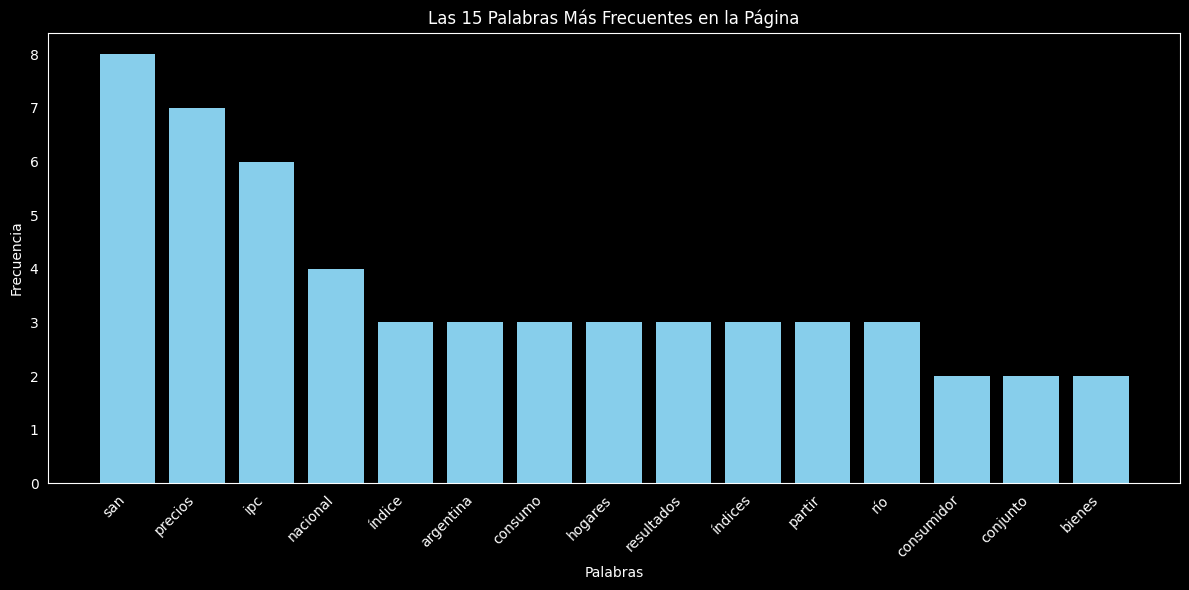

In [69]:
import matplotlib.pyplot as plt
from collections import Counter

# Calcular la frecuencia de las palabras
word_frequencies = Counter(filtered_tokens)

# Obtener las 15 palabras más frecuentes
most_common_words = word_frequencies.most_common(15)

# Preparar los datos para el gráfico
words = [word for word, freq in most_common_words]
frequencies = [freq for word, freq in most_common_words]

# Crear el gráfico de barras con fondo negro
plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.bar(words, frequencies, color='skyblue')
plt.xlabel('Palabras', color='white')
plt.ylabel('Frecuencia', color='white')
plt.title('Las 15 Palabras Más Frecuentes en la Página', color='white')
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(color='white')

# Cambiar color de los bordes
for spine in ax.spines.values():
    spine.set_color('white')

plt.tight_layout()
plt.show()

***Comentario sobre la visualización:***
Sí, en la visualización surgieron algunos tokens que también podrían considerarse stopwords. Por ejemplo, “**no**” puede clasificarse como una stopword general del español, ya que es una palabra funcional muy frecuente. En cambio, “**san**” no es una stopword clásica, pero en este documento aparece repetidamente como parte de nombres geográficos, por lo que puede tratarse como una stopword específica del corpus. Del mismo modo, términos como “**ipc**” o “**nacional**” también podrían eliminarse si se busca resaltar palabras más informativas sobre el contenido temático del texto.

# Conclusión general:
A lo largo de este trabajo se logró construir un flujo completo de procesamiento de un archivo PDF en Python, desde su descarga automática hasta la obtención de datos listos para analizar. Primero se accedió a los metadatos del documento, luego se exploró su estructura textual, se extrajo y limpió una tabla en formato DataFrame, y finalmente se aplicaron técnicas básicas de NLP para tokenizar, limpiar y visualizar las palabras más frecuentes de una página con texto narrativo. En conjunto, el práctico permitió comprobar que, aunque los PDF presentan dificultades por su estructura interna, con las librerías adecuadas es posible transformar su contenido en información estructurada y útil para futuros análisis.